# 🏠 Tehran House Price Analysis & Cleaning
### Enhanced EDA and Visualization
Prepared by Sahar ✨
---
In this notebook, we will clean, explore, and visualize Tehran housing data to prepare it for predictive modeling.

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

## 1️⃣ Data Loading and Overview

In [31]:
print('Loading dataset...')
df = pd.read_csv('../data/housePrice.csv')

print(f"Dataset shape: {df.shape}")
display(df.head())
df.info()

Loading dataset...
Dataset shape: (3479, 8)


,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   object 
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   object 
 6   Price       3479 non-null   float64
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(2), int64(1), object(2)
memory usage: 146.2+ KB


## 2️⃣ Cleaning Numeric Columns

In [32]:
def clean_numeric_column(series):
    cleaned = series.astype(str).str.replace(',', '').str.replace(' ', '').str.strip()
    cleaned = cleaned.replace(['', 'nan', 'None', 'null', 'NaN'], np.nan)
    cleaned = pd.to_numeric(cleaned, errors='coerce')
    return cleaned.astype(float)

In [33]:
# Drop redundant Price(USD)
if 'Price(USD)' in df.columns:
    df.drop(columns=['Price(USD)'], inplace=True)
    print('Dropped Price(USD) column.')

# Clean key numeric columns
df['Area'] = clean_numeric_column(df['Area'])
df['Price'] = clean_numeric_column(df['Price'])

# Remove invalid or missing values
df = df[(df['Area'] > 0) & (df['Price'] > 0) & df['Address'].notna()]
print(f"Cleaned dataset shape: {df.shape}")
df.head()

Dropped Price(USD) column.
Cleaned dataset shape: (3456, 7)


,Area,Room,Parking,Warehouse,Elevator,Address,Price
0,63.0,1,True,True,True,Shahran,1.850000e+09
1,60.0,1,True,True,True,Shahran,1.850000e+09
2,79.0,2,True,True,True,Pardis,5.500000e+08
3,95.0,2,True,True,True,Shahrake Qods,9.025000e+08
4,123.0,2,True,True,True,Shahrake Gharb,7.000000e+09


## 3️⃣ Feature Engineering

In [34]:
df['Price_Million'] = df['Price'] / 1_000_000
df['Price_per_sqm'] = df['Price'] / df['Area']
df['Price_per_sqm_Million'] = df['Price_per_sqm'] / 1_000_000
df[['Area', 'Price_Million', 'Price_per_sqm_Million']].describe().round(2)

,Area,Price_Million,Price_per_sqm_Million
count,3.456000e+03,3456.00,3456.00
mean,8.802191e+06,5379.96,41.21
std,3.177783e+08,8121.73,31.67
min,3.000000e+01,3.60,0.00
25%,6.900000e+01,1420.00,20.00
50%,9.000000e+01,2900.00,34.67
75%,1.210000e+02,6000.00,54.94
max,1.616000e+10,92400.00,416.67


## 4️⃣ Remove Outliers (Location-aware)

In [35]:
def remove_all_outliers(df, numeric_cols=None, group_col='Address', factor=1.5):
    """
    Remove outliers from all numeric columns, optionally grouping by a column (e.g. Address).
    Uses IQR (Interquartile Range) method.
    """
    if numeric_cols is None:
        # Select numeric columns automatically
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    print(f"\n🔍 Removing outliers for columns: {numeric_cols}")
    print(f"Grouping by: {group_col} (if applicable)")

    cleaned_dfs = []
    total_removed = 0

    for group, group_df in df.groupby(group_col):
        group_original_count = len(group_df)
        group_clean = group_df.copy()

        for col in numeric_cols:
            if group_clean[col].nunique() > 5:  # skip constant or small sets
                Q1 = group_clean[col].quantile(0.25)
                Q3 = group_clean[col].quantile(0.75)
                IQR = Q3 - Q1
                lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
                group_clean = group_clean[(group_clean[col] >= lower) & (group_clean[col] <= upper)]

        removed = group_original_count - len(group_clean)
        total_removed += removed

        if removed > 0:
            print(f"  {group}: removed {removed} outliers")
        cleaned_dfs.append(group_clean)

    result_df = pd.concat(cleaned_dfs, ignore_index=True)
    print(f"\n✅ Total outliers removed: {total_removed}")
    print(f"Final dataset size: {len(result_df)}")
    return result_df
numeric_cols = ['Area', 'Price', 'Price_per_sqm', 'Price_per_sqm_Million', 'Room']
df = remove_all_outliers(df, numeric_cols=numeric_cols, group_col='Address', factor=1.5)



🔍 Removing outliers for columns: ['Area', 'Price', 'Price_per_sqm', 'Price_per_sqm_Million', 'Room']
Grouping by: Address (if applicable)
  Abazar: removed 2 outliers
  Afsarieh: removed 1 outliers
  Air force: removed 1 outliers
  Amirabad: removed 4 outliers
  Amirieh: removed 4 outliers
  Andisheh: removed 16 outliers
  Aqdasieh: removed 9 outliers
  Araj: removed 3 outliers
  Azarbaijan: removed 5 outliers
  Baghestan: removed 1 outliers
  Beryanak: removed 4 outliers
  Central Janatabad: removed 11 outliers
  Damavand: removed 2 outliers
  Dehkade Olampic: removed 2 outliers
  Dezashib: removed 3 outliers
  Dorous: removed 3 outliers
  East Ferdows Boulevard: removed 12 outliers
  East Pars: removed 2 outliers
  Ekbatan: removed 1 outliers
  Ekhtiarieh: removed 9 outliers
  Fallah: removed 1 outliers
  Gheitarieh: removed 12 outliers
  Gisha: removed 3 outliers
  Golestan: removed 2 outliers
  Hashemi: removed 2 outliers
  Heravi: removed 7 outliers
  Hor Square: removed 1 outlie

## 5️⃣ Visualization

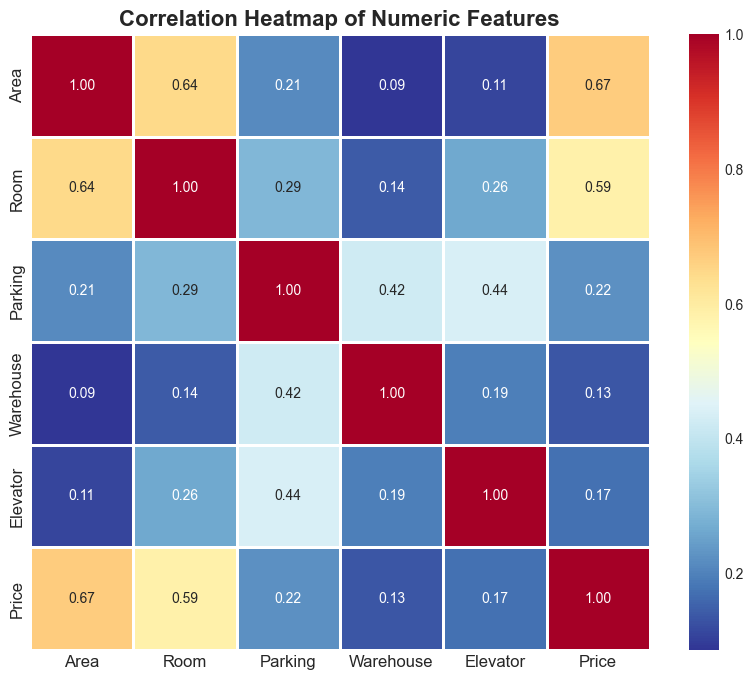

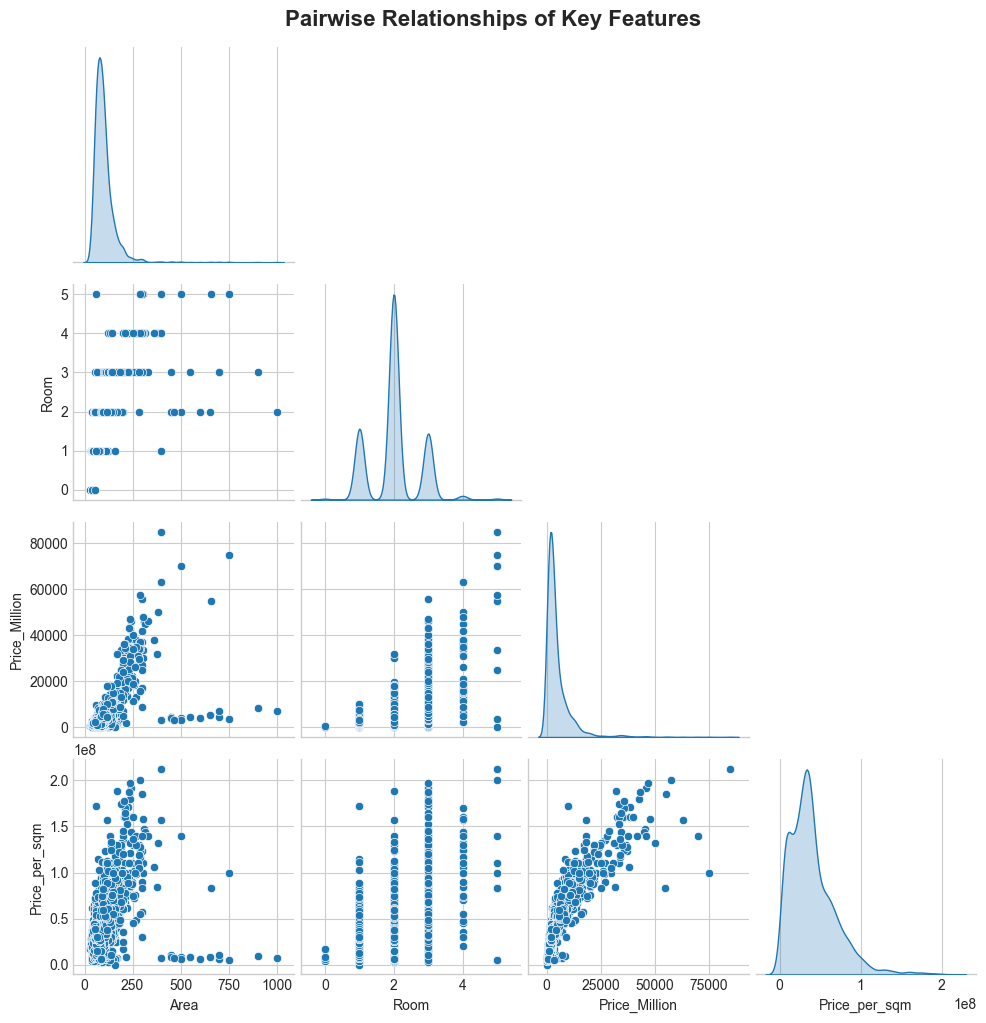

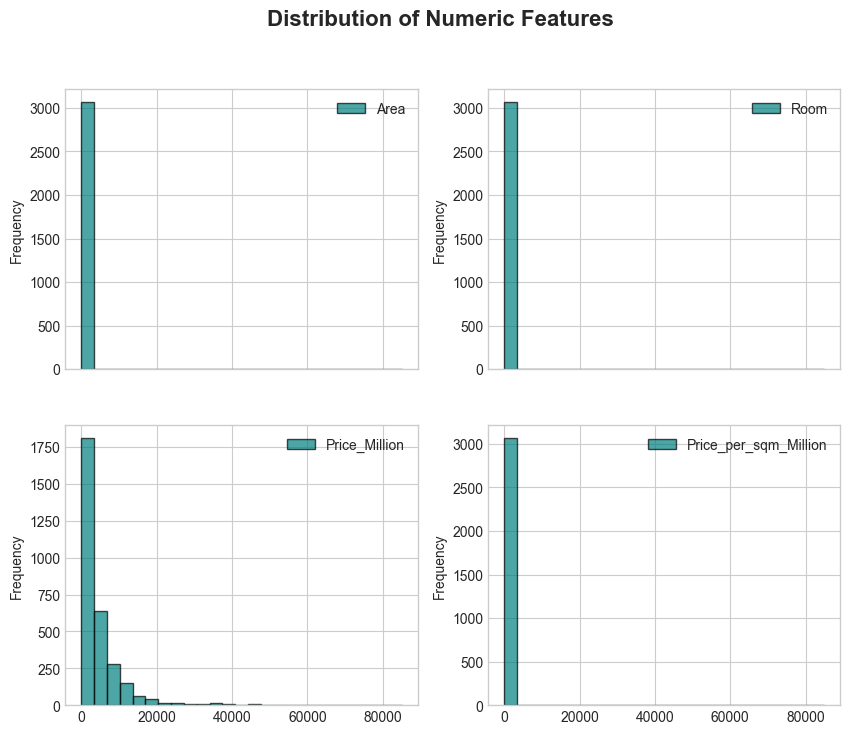

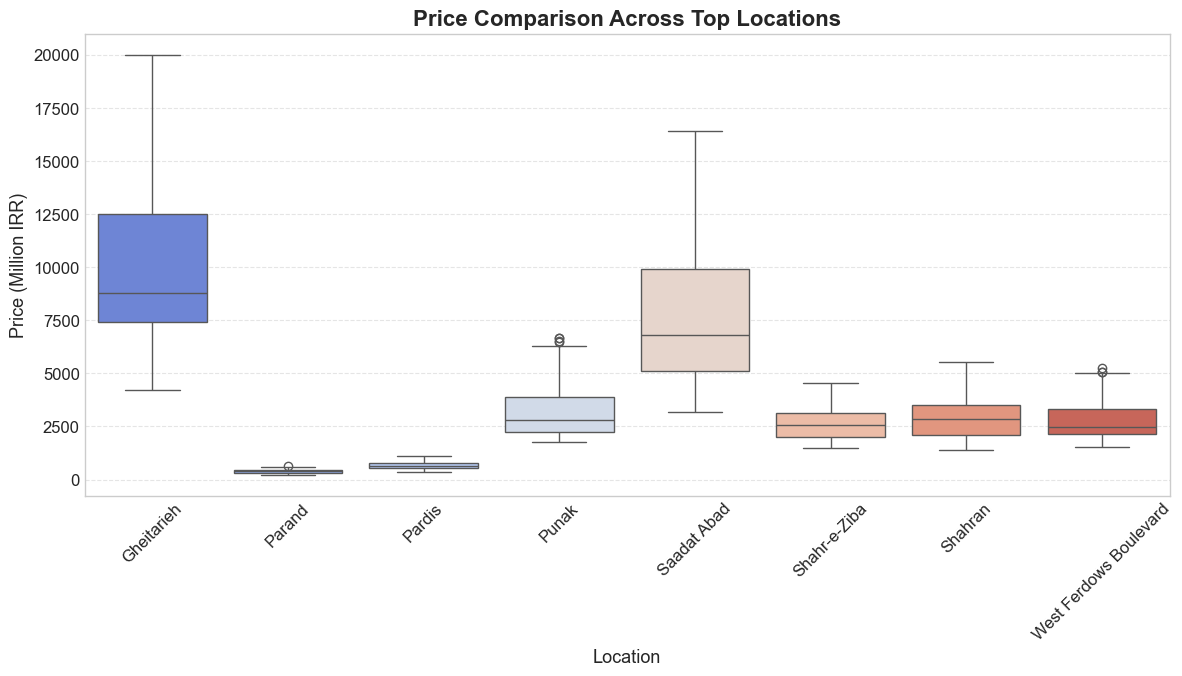

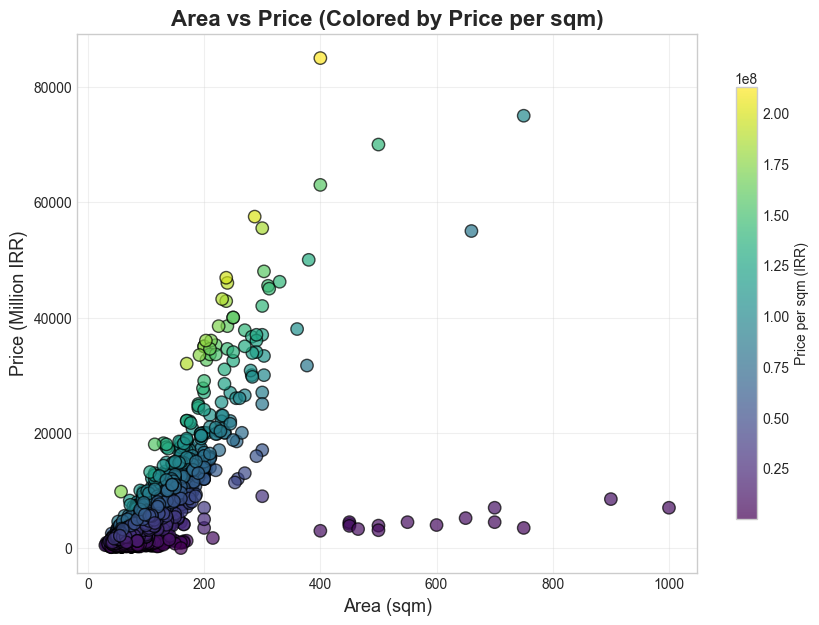

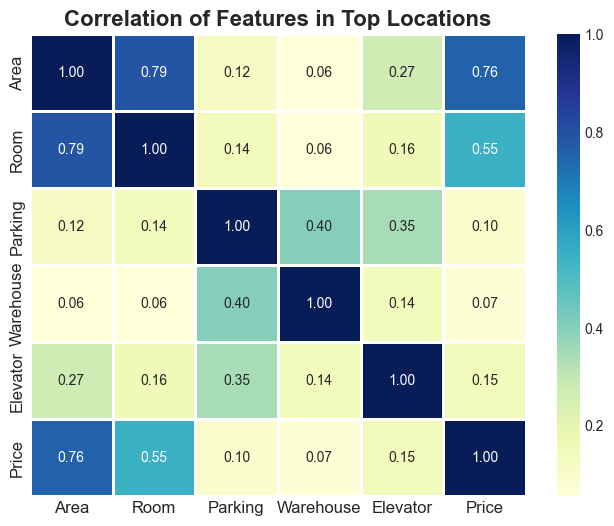

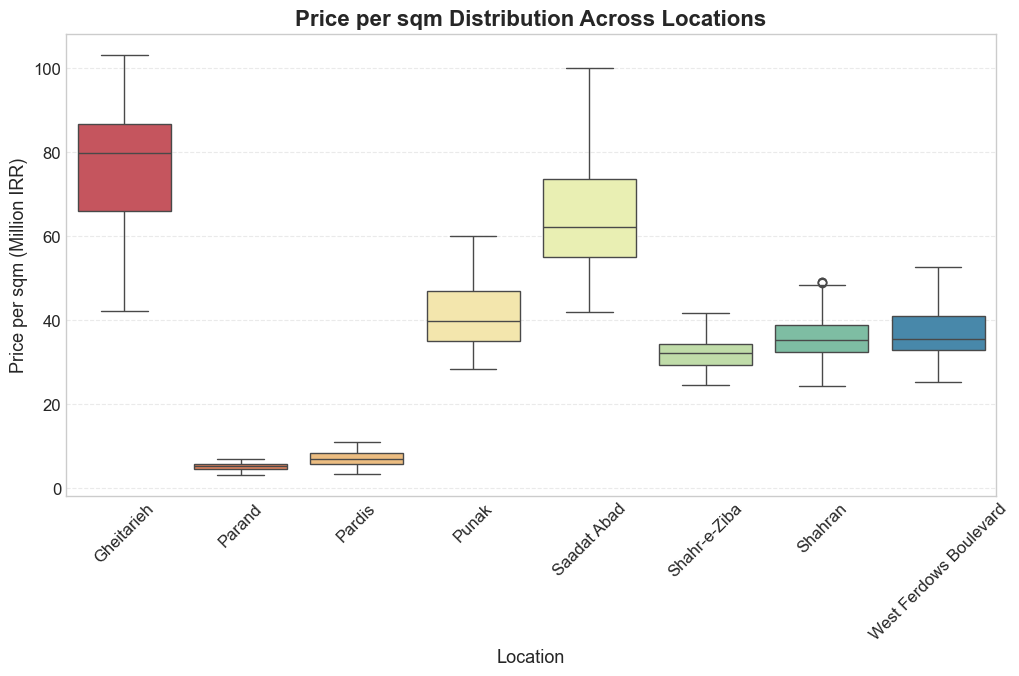

In [45]:
# 🟦 سلول ۱ — Correlation Heatmap (Presentation-ready)

plt.figure(figsize=(10,8))
corr_matrix = df[['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Price']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', fmt=".2f", linewidths=1, linecolor='white')
plt.title('Correlation Heatmap of Numeric Features', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()





# 🟦 سلول 2 — Pairplot (Presentation-ready)


sns.pairplot(df[['Area', 'Room', 'Price_Million', 'Price_per_sqm']], 
             diag_kind='kde', corner=True, palette='Set2')
plt.suptitle('Pairwise Relationships of Key Features', y=1.02, fontsize=16, fontweight='bold')
plt.savefig('../plots/Pairplot (Presentation-ready).png', dpi=300, bbox_inches='tight')

plt.show()



### 🟦 سلول 3 — Distribution (Histogram + KDE)


numeric_features = ['Area', 'Room', 'Price_Million', 'Price_per_sqm_Million']
df[numeric_features].plot(kind='hist', bins=25, figsize=(10,8), alpha=0.7, subplots=True, layout=(2,2), color='teal', edgecolor='black')
plt.suptitle('Distribution of Numeric Features', fontsize=16, fontweight='bold')
plt.savefig('../plots/Distribution (Histogram + KDE).png', dpi=300, bbox_inches='tight')

plt.show()


### 🟦 سلول 4 — Boxplot by Location


plt.figure(figsize=(14,6))
top_locations = df['Address'].value_counts().head(8).index
sns.boxplot(data=df[df['Address'].isin(top_locations)], 
            x='Address', y='Price_Million', palette='coolwarm')
plt.title('Price Comparison Across Top Locations', fontsize=16, fontweight='bold')
plt.xlabel('Location', fontsize=13)
plt.ylabel('Price (Million IRR)', fontsize=13)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('../plots/ Boxplot by Location.png', dpi=300, bbox_inches='tight')

plt.show()


### 🟦 سلول 5 — Scatter (Area vs Price, Colored by Price per sqm)


plt.figure(figsize=(10,7))
scatter = plt.scatter(df['Area'], df['Price_Million'], 
                      c=df['Price_per_sqm'], cmap='viridis', alpha=0.7, s=80, edgecolor='k')
plt.colorbar(scatter, label='Price per sqm (IRR)', shrink=0.8)
plt.xlabel('Area (sqm)', fontsize=13)
plt.ylabel('Price (Million IRR)', fontsize=13)
plt.title('Area vs Price (Colored by Price per sqm)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('../plots/ Scatter (Area vs Price, Colored by Price per sqm).png', dpi=300, bbox_inches='tight')

plt.show()


### 🟦 سلول 6 — Heatmap for Top Locations


top_addresses = df['Address'].value_counts().head(5).index
subset = df[df['Address'].isin(top_addresses)]
corr_subset = subset[['Area','Room','Parking','Warehouse','Elevator','Price']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_subset, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=1, linecolor='white')
plt.title('Correlation of Features in Top Locations', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('../plots/ Heatmap for Top Locations.png', dpi=300, bbox_inches='tight')
plt.show()

### 🟦 سلول 7 — Boxplot (Price per sqm by Location)


plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['Address'].isin(top_locations)], 
            x='Address', y='Price_per_sqm_Million', palette='Spectral')
plt.title('Price per sqm Distribution Across Locations', fontsize=16, fontweight='bold')
plt.ylabel('Price per sqm (Million IRR)', fontsize=13)
plt.xlabel('Location', fontsize=13)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('../plots/ Boxplot (Price per sqm by Location).png', dpi=300, bbox_inches='tight')

plt.show()




from IPython.display import Markdown

summary_text = """
# 📝 EDA Summary: Tehran Housing Dataset

**1. Correlation Insights**
- 'Price' is strongly correlated with 'Area' and moderately with 'Room'.
- Amenities such as 'Parking', 'Warehouse', and 'Elevator' influence price more significantly in premium neighborhoods.

**2. Distributions**
- Most properties are between 60–100 sqm.
- Price distribution is right-skewed, indicating few high-value properties.
- Price per sqm varies considerably across locations.

**3. Neighborhood Analysis**
- Northern and central locations show higher average prices.
- Price variability is higher in top-demand areas.
- Amenities impact pricing more in specific neighborhoods.

**4. Scatter Observations**
- Larger properties tend to cost more, but price per sqm may decrease for very large apartments.
- Mid-sized apartments in premium areas can have higher price per sqm than larger apartments in less expensive districts.

**5. Conclusion**
- **Area** is the primary driver of price.
- **Location and amenities** significantly affect valuation.
- Features to include for modeling: 'Area', 'Room', 'Address', and key amenities.
- Handle outliers and skewed prices carefully during model training.
"""

display(Markdown(summary_text))


## 6️⃣ Correlation Analysis

Correlation with Price:


Price        1.000000
Area         0.670276
Room         0.585183
Parking      0.222892
Elevator     0.174659
Warehouse    0.134905
Name: Price, dtype: float64

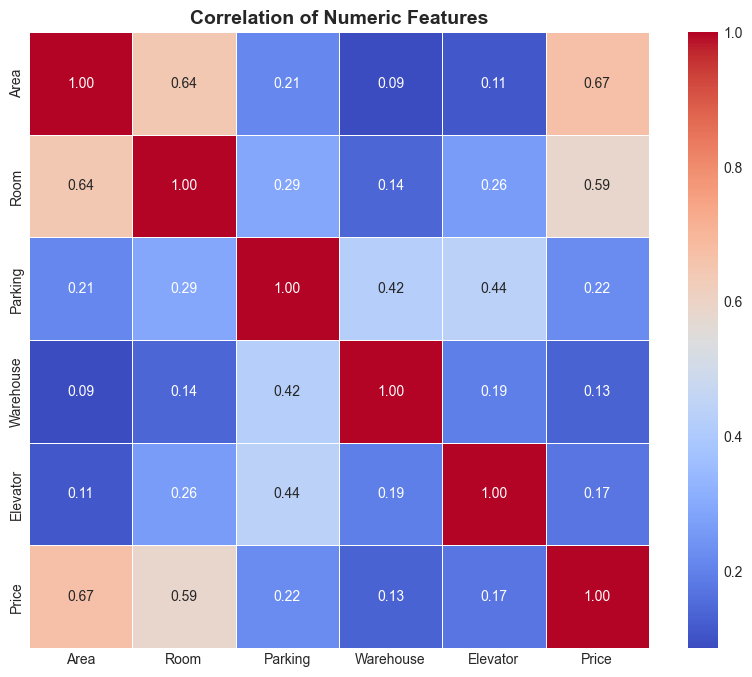

In [44]:
corr = df[['Area','Room','Parking','Warehouse','Elevator','Price']].corr()['Price'].sort_values(ascending=False)
print('Correlation with Price:')
display(corr)


# 🔹 بررسی همبستگی بین ویژگی‌های عددی

plt.figure(figsize=(10,8))
corr_matrix = df[['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Price']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation of Numeric Features', fontsize=14, fontweight='bold')
plt.show()


## 7️⃣ Save Cleaned Dataset

In [38]:
df.to_csv('../data/cleaned_housePrice_enhanced.csv', index=False)
print("✅ Enhanced cleaned dataset saved successfully!")

✅ Enhanced cleaned dataset saved successfully!
